In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# MONTER LE DRIVE
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# chargement du model entrainé
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/Projet_Riz/rice_mobilenetv2_final.keras")


In [ ]:
#générateur pour le test externe
from tensorflow.keras.preprocessing.image import ImageDataGenerator

external_path = "/content/drive/MyDrive/Projet_Riz/dataset_externe"

external_datagen = ImageDataGenerator(rescale=1./255)

external_generator = external_datagen.flow_from_directory(
    external_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 75048 images belonging to 5 classes.


In [ ]:
# évaluation du model sur le dataset externe
external_loss, external_acc = model.evaluate(external_generator)

print("External dataset accuracy :", external_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2346/2346 ━━━━━━━━━━━━━━━━━━━━ 23530s 10s/step - accuracy: 0.9515 - loss: 0.1447
External dataset accuracy : 0.9370003342628479


Nombre d'images externes : 75048
2346/2346 ━━━━━━━━━━━━━━━━━━━━ 2950s 1s/step


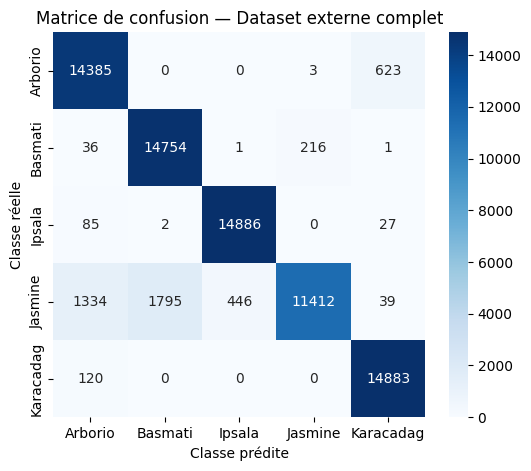

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Vérification que le générateur existe
print("Nombre d'images externes :", external_generator.samples)

# Labels réels
y_true = external_generator.classes

# Prédictions du modèle
y_pred_prob = model.predict(external_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

# Noms des classes
class_names = list(external_generator.class_indices.keys())

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Matrice de confusion — Dataset externe complet")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()


In [ ]:
# sauvegarde du model
model.save("rice_validation.keras")


In [ ]:
!cp rice_validation.keras /content/drive/MyDrive/Projet_Riz
